Graph test

In [178]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [179]:
import os
import sys

import cv2

import numpy as np 

import torch
import torch.nn as nn
import torch.nn.functional as F

from box import Box
import yaml

import matplotlib.pyplot as plt

from scipy.spatial.transform import Rotation as R
import random 

import time 

root_dir = os.path.abspath('../..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.models.graph import Graph

# from src.data_loader.transforms_numpy import polar2cartesian, addSpeckleNoise, energyLoss, addBandReflects



In [180]:
model_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/model.yaml'
sonar_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/sonar.yaml'

with open(model_config_pth, "r") as f:
    model_config = Box(yaml.safe_load(f))

with open(sonar_config_pth, "r") as f:
    sonar_config = Box(yaml.safe_load(f))

PatchGraph = Graph(model_config, sonar_config)

# init test configuration
PatchGraph.patches_per_frame = 5
PatchGraph.time_window = 3

In [181]:
# test data 

data_pth_sim = f'C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/seq_1/fls/352.png'

# read frame 
frame_sim = cv2.imread(data_pth_sim, 0)

frame_sim = frame_sim.astype(np.uint8)
frame_sim = torch.from_numpy(frame_sim) # convert to torch tensor
frame_sim = frame_sim.float().unsqueeze(0).unsqueeze(0).unsqueeze(0)

print('-'*80)
print(f'Input data format:')
print(f'simulated tensor shape: {frame_sim.shape}, data type: {frame_sim.dtype}')
print('-'*80)

--------------------------------------------------------------------------------
Input data format:
simulated tensor shape: torch.Size([1, 1, 1, 800, 768]), data type: torch.float32
--------------------------------------------------------------------------------


### Test 3 `Appro movement`

In [182]:
def plot_test_case(title, p_prev, p_last, p_pred, p_expected=None):
    def to_np(x):
        if x is None: return None
        # Jeśli to już numpy, zwróć. Jeśli tensor, skonwertuj.
        if torch.is_tensor(x): return x.detach().cpu().numpy()
        return x

    # Konwersja wszystkich wejść
    p_prev_np = to_np(p_prev)
    p_last_np = to_np(p_last)
    p_pred_np = to_np(p_pred)
    p_expected_np = to_np(p_expected)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    def draw_frame_full(pose_np, label, length=0.2, is_pred=False):
        pos = pose_np[:3]
        quat = pose_np[3:]
        
        # Rysujemy główny punkt
        size = 150 if is_pred else 100
        ax.scatter(pos[0], pos[1], pos[2], label=label, s=size, edgecolors='k')

        # Obliczamy rotację
        norm = np.linalg.norm(quat)
        if norm > 1e-6:
            r = R.from_quat(quat / norm)
            rot_mat = r.as_matrix()
            
            # Osie: X=czerwony, Y=zielony, Z=niebieski
            colors = ['r', 'g', 'b']
            for i in range(3):
                ax.quiver(pos[0], pos[1], pos[2], 
                          rot_mat[0, i], rot_mat[1, i], rot_mat[2, i], 
                          color=colors[i], length=length, normalize=True, alpha=0.8)
        else:
            print(f"Warning: Zero norm quat for {label}")

    # Rysowanie klatek
    draw_frame_full(p_prev_np, 't_(k-2)')
    draw_frame_full(p_last_np, 't_(k-1)')
    draw_frame_full(p_pred_np, 't_k prediction', length=0.4, is_pred=True)
    
    # Rysowanie punktu oczekiwanego (jeśli podano)
    if p_expected_np is not None:
        pos_ex = p_expected_np[:3]
        ax.scatter(pos_ex[0], pos_ex[1], pos_ex[2], 
                   c='black', marker='x', s=200, label='t_k expected', linewidths=3)
        # Opcjonalnie: dorysowanie osi dla oczekiwanego (półprzezroczyste)
        draw_frame_full(p_expected_np, 'expected', length=0.2)

    # Linia trajektorii
    path = np.array([p_prev_np[:3], p_last_np[:3], p_pred_np[:3]])
    ax.plot(path[:,0], path[:,1], path[:,2], 'k--', alpha=0.4)

    ax.set_title(title)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.legend()
    
    # Automatyczne skalowanie z lekkim marginesem
    all_coords = np.vstack([p_prev_np[:3], p_last_np[:3], p_pred_np[:3]])
    if p_expected_np is not None:
        all_coords = np.vstack([all_coords, p_expected_np[:3]])
        
    mins = all_coords.min(axis=0)
    maxs = all_coords.max(axis=0)
    center = (mins + maxs) / 2
    dist = max(maxs - mins) / 2 + 0.2 # margines
    
    ax.set_xlim(center[0] - dist, center[0] + dist)
    ax.set_ylim(center[1] - dist, center[1] + dist)
    ax.set_zlim(center[2] - dist, center[2] + dist)
    
    plt.show()

--------------------------------------------------
Movement:
    shift:
    x:0.2866642564638513
    y:0.4007149789951445
    z:0.008718601496175316
    rotation:
    x: 0
    y: 0
    z: 82
Motion model: LINEAR
predicted pose for time t_k-2: tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.6561, 0.7547],
       dtype=torch.float64)
predicted pose for time t_k-1: tensor([0.2867, 0.4007, 0.0087, 0.0000, 0.0000, 0.9903, 0.1392],
       dtype=torch.float64)
predicted pose for time t_k: tensor([ 0.5733,  0.8014,  0.0174,  0.0000,  0.0000,  0.8387, -0.5446])


C:\Users\janis\AppData\Local\Temp\ipykernel_22912\3094932314.py:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  PatchGraph.poses[n-2, :] = torch.tensor(p_t2)
C:\Users\janis\AppData\Local\Temp\ipykernel_22912\3094932314.py:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  PatchGraph.poses[n-1, :] = torch.tensor(p_t1)


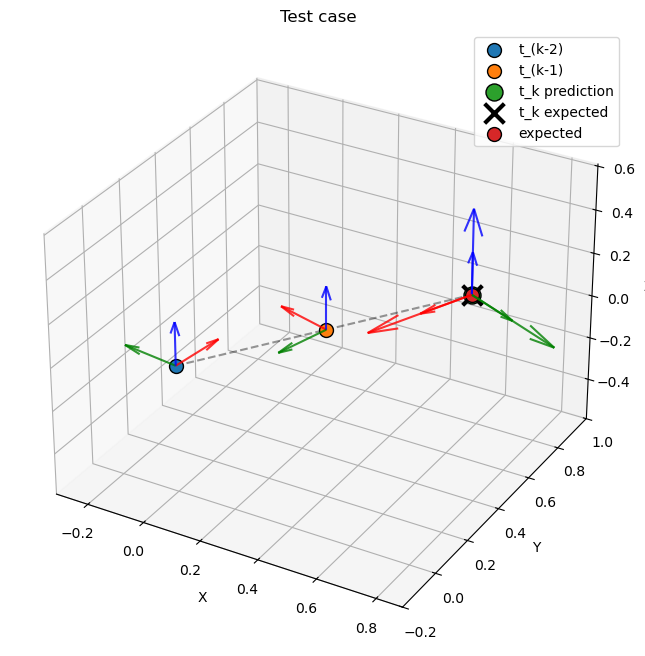

>    Result: PASSED


In [183]:
# Test data:

# rotation

t_k_2 = 0.5
t_k_1 = 1.0
t_k_0 = 1.5

rot_1_deg = random.randint(0, 90)
rot_2_deg = 2 * rot_1_deg
rot_3_deg = (t_k_0 - t_k_1) / (t_k_1 - t_k_2) * rot_1_deg  + rot_2_deg

# shift 
shift = np.array([random.random(), random.random(), random.random()])

# combine movements
# q_0deg = R.from_euler('z', 0 , degrees=True).as_quat() # init rotation - 0 deg 
q_1 = R.from_euler('z', rot_1_deg , degrees=True).as_quat() # rotation 1 - quaterions
q_2 = R.from_euler('z', rot_2_deg, degrees=True).as_quat() # rotation 2 - 2 * rotation 1 - quaterions
q_3 = R.from_euler('z', rot_3_deg, degrees=True).as_quat() # rotation 3 - 4 * rotation 1 - quaterions

p_t2 = torch.tensor(np.concatenate([[0,0,0], q_1]))  # for time t_k-2
p_t1 = torch.tensor(np.concatenate([shift, q_2]))  # for time t_k-1

# Expected point for time t_k
p_t0  = torch.tensor(np.concatenate([2*shift, q_3]), dtype=torch.float32)

print('-'*50)
print(f'Movement:')
print(f'    shift:\n    x:{shift[0]}\n    y:{shift[1]}\n    z:{shift[2]}')
print(f'    rotation:\n    x: 0\n    y: 0\n    z: {rot_1_deg}')

n = 4

PatchGraph.frame_n = n

PatchGraph.poses[n-2, :] = torch.tensor(p_t2)
PatchGraph.poses[n-1, :] = torch.tensor(p_t1)

PatchGraph.time[n-2] = 0.5 #torch.tensor(0.5)
PatchGraph.time[n-1] = 1.0 #torch.tensor(1.0)
PatchGraph.time[n] = 1.5 #torch.tensor(1.5)

print(f'Motion model: {PatchGraph.motion_model}')

PatchGraph.approx_movement()

p_pred = PatchGraph.poses[n, :]

print(f'predicted pose for time t_k-2: {p_t2}')
print(f'predicted pose for time t_k-1: {p_t1}')
print(f'predicted pose for time t_k: {p_pred}')
plot_test_case('Test case', p_t2, p_t1, p_pred, p_expected=p_t0)

if all(list(p_pred.detach().cpu())) == all(list(p_t0.detach().cpu())):
    print('>    Result: PASSED')
else:
    print('>    Result: FAILED')

### Test 4 `Create edges`



In [184]:
frame = frame_sim 
time_stamp = 0.123

PatchGraph.frame_n = 4

coords, new_patches, fmap, imap = PatchGraph.patchifier(frame, mode = 'harris')
PatchGraph.add_frame(fmap, imap, time_stamp)
PatchGraph.add_patches(new_patches, coords)
PatchGraph.approx_movement()
PatchGraph.create_edges()


i = PatchGraph.i
j = PatchGraph.j

idx_low = (PatchGraph.frame_n % PatchGraph.buff_size) * PatchGraph.patches_per_frame * PatchGraph.time_window * 2
idx_high = ((PatchGraph.frame_n + 1) % PatchGraph.buff_size) * PatchGraph.patches_per_frame * PatchGraph.time_window * 2

# expected values calculated manually
i_expected = torch.tensor([20, 21, 22, 23, 24, 20, 21, 22, 23, 24, 20, 21, 22, 23, 24,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])
j_expected = torch.tensor([3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4])


if all(list(i[idx_low:idx_high].detach().cpu())) == all(list(i_expected.detach().cpu())) and all(list(j[idx_low:idx_high].detach().cpu())) == all(list(j_expected.detach().cpu())):
    print('> Result: PASSED')
else:
    print('> Result: FAILED')

torch.set_printoptions(threshold=float('inf'))
print(f'i:')
print(i[idx_low:idx_high])
print(f'j:')
print(j[idx_low:idx_high])

> Result: PASSED
i:
tensor([20, 21, 22, 23, 24, 20, 21, 22, 23, 24, 20, 21, 22, 23, 24,  5,  6,  7,
         8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19], dtype=torch.int32)
j:
tensor([3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4], dtype=torch.int32)


### Test 5 `Correlation`

In [ ]:
time_stamp = 2.5
time_interval = 0.5

for _ in range(12):
    time_stamp += time_interval
    t0 = time.time()
    PatchGraph(frame_sim, time_stamp)
    t1 = time.time()

    print(f'execution time: {t1-t0}')

torch.Size([30, 128, 9, 25]) * torch.Size([30, 128, 9]) = torch.Size([30, 25])
torch.Size([30, 128, 9, 25]) * torch.Size([30, 128, 9]) = torch.Size([30, 25])
execution time: 0.6731936931610107
torch.Size([60, 128, 9, 25]) * torch.Size([60, 128, 9]) = torch.Size([60, 25])
torch.Size([60, 128, 9, 25]) * torch.Size([60, 128, 9]) = torch.Size([60, 25])
execution time: 1.0890069007873535
torch.Size([89, 128, 9, 25]) * torch.Size([89, 128, 9]) = torch.Size([89, 25])
torch.Size([89, 128, 9, 25]) * torch.Size([89, 128, 9]) = torch.Size([89, 25])
execution time: 1.0589244365692139
torch.Size([117, 128, 9, 25]) * torch.Size([117, 128, 9]) = torch.Size([117, 25])
torch.Size([117, 128, 9, 25]) * torch.Size([117, 128, 9]) = torch.Size([117, 25])
execution time: 1.6019816398620605
torch.Size([145, 128, 9, 25]) * torch.Size([145, 128, 9]) = torch.Size([145, 25])
torch.Size([145, 128, 9, 25]) * torch.Size([145, 128, 9]) = torch.Size([145, 25])
execution time: 1.8773958683013916
torch.Size([172, 128, 9